# Monte Carlo Option Pricing

This notebook prices a European call option using Monte Carlo simulation and compares the result to the closed-form Black-Scholes price.

---

## 1. The Idea

Instead of solving analytically, we simulate thousands of possible futures for the stock price and average the discounted payoffs:

$$\hat{C} = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \max(S_T^{(i)} - K,\ 0)$$

Each simulated final price $S_T^{(i)}$ is drawn from the GBM formula:

$$S_T = S_0 \cdot \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T} \cdot Z\right), \quad Z \sim \mathcal{N}(0,1)$$

As $N \to \infty$, the Monte Carlo price converges to the Black-Scholes price.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from monte_carlo import monte_carlo_call
from black_scholes import black_scholes_call

## 2. Single Simulation

In [7]:
S, K, T, r, sigma = 150, 155, 0.5, 0.05, 0.20

# n = the number of simulations
mc_price = monte_carlo_call(S, K, T, r, sigma, n=100_000)
bs_price = black_scholes_call(S, K, T, r, sigma)

print(f"Monte Carlo price: ${mc_price:.4f}")
print(f"Black-Scholes price: ${bs_price:.4f}")
print(f"Difference: ${abs(mc_price - bs_price):.4f}")

Monte Carlo price: $7.8972
Black-Scholes price: $7.9152
Difference: $0.0180


## 3. Convergence Analysis

The Monte Carlo estimate is noisy for small $N$ and converges to the true price as $N$ increases. We can visualize this convergence directly.

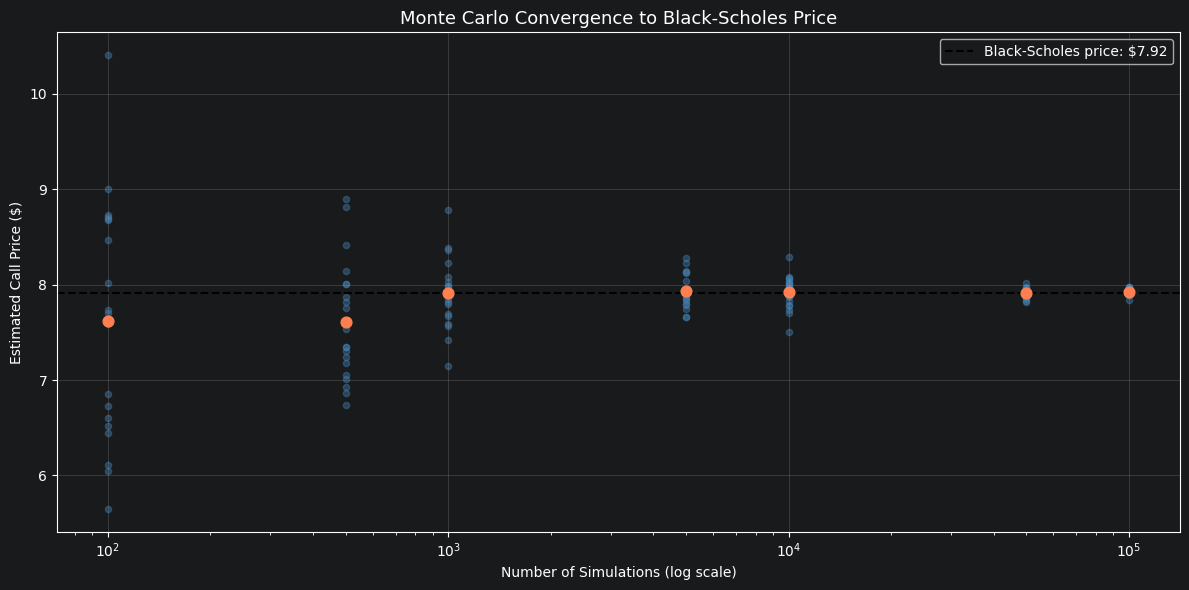

In [5]:
simulation_counts = [100, 500, 1000, 5000, 10000, 50000, 100000]
n_repeats = 20  # run each count multiple times to show variance

results = {}
for n in simulation_counts:
    prices = [monte_carlo_call(S, K, T, r, sigma, n=n) for _ in range(n_repeats)]
    results[n] = prices

# plot
fig, ax = plt.subplots(figsize=(12, 6))

for n, prices in results.items():
    ax.scatter([n] * n_repeats, prices, alpha=0.4, s=20, color="steelblue")
    ax.scatter(n, np.mean(prices), color="coral", s=60, zorder=5)

ax.axhline(y=bs_price, color="black", linestyle="--", linewidth=1.5,
           label=f"Black-Scholes price: ${bs_price:.2f}")
ax.set_xscale("log")
ax.set_title("Monte Carlo Convergence to Black-Scholes Price", fontsize=13)
ax.set_xlabel("Number of Simulations (log scale)")
ax.set_ylabel("Estimated Call Price ($)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/mc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Simulated Price Paths

Rather than just the final price, we can visualize the full path each simulated stock takes over the option's life.

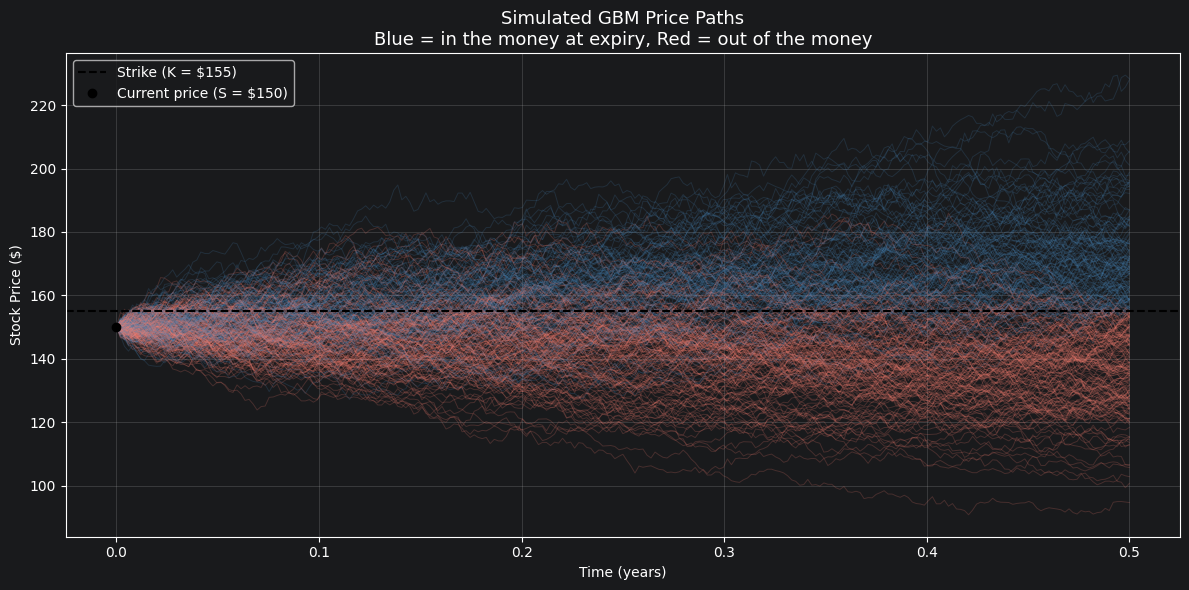

In [6]:
import sys
sys.path.append('../src')
from visualize import simulate_paths

paths, time = simulate_paths(S, T, r, sigma, n_paths=300, n_steps=252)

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(300):
    color = "steelblue" if paths[-1, i] > K else "salmon"
    ax.plot(time, paths[:, i], color=color, alpha=0.2, linewidth=0.7)

ax.axhline(y=K, color="black", linestyle="--", linewidth=1.5,
           label=f"Strike (K = ${K})")
ax.plot(0, S, "ko", markersize=6, label=f"Current price (S = ${S})")
ax.set_title("Simulated GBM Price Paths\nBlue = in the money at expiry, Red = out of the money",
             fontsize=13)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Stock Price ($)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/price_paths.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- Monte Carlo prices options by simulating thousands of possible futures and averaging discounted payoffs
- With 100,000 simulations the price typically matches Black-Scholes to within a few cents
- The estimate is noisy at low simulation counts and converges as $N$ increases, visible clearly in the convergence plot
- The blue/red path visualization shows which simulated futures end in the money